## Proyecto CNN: Clasificación de imágenes de zacudos transmisores de enfermedades virales en Madre de Dios

### Etapa 1: Tratamiento de datos

In [13]:
import os
import shutil
from pathlib import Path
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [14]:
SOURCE_DIR = Path('MLMI-2024')
TARGET_DIR = Path('dataset')
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# Detectar clases

classes = [d for d in SOURCE_DIR.iterdir() if d.is_dir()]

# Crear carpetas destino
for cls in classes:
    (TARGET_DIR / cls.name).mkdir(parents=True, exist_ok=True)

# Copiar y contar imagenes

image_count = {cls.name: 0 for cls in classes}

for cls in classes:
    for subfolder in cls.iterdir():
        if not subfolder.is_dir():
            continue

        for img_path in subfolder.iterdir():
            if img_path.suffix.lower() in VALID_EXTENSIONS:
                target_path = TARGET_DIR / cls.name / img_path.name
                shutil.copy2(img_path, target_path)
                image_count[cls.name] += 1

# Resumen

print("\nDataset unificado:")
for cls, count in image_count.items():
    print(f" - {cls}: {count} imágenes")


Dataset unificado:
 - Aedes aegypti: 400 imágenes
 - Culex quinquefasciatus: 400 imágenes


### Etapa 2: Visualización de datos

In [15]:
from torchvision import datasets
import matplotlib.pyplot as plt
import random


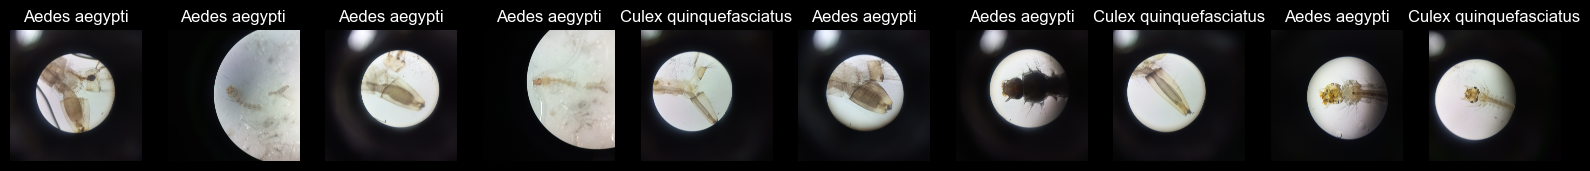

In [16]:
DATASET_DIR = "dataset"
N = 10  # número de imágenes a mostrar

# Cargar dataset
dataset_raw = datasets.ImageFolder(root=DATASET_DIR)

# Seleccionar imágenes aleatorias
indices = random.sample(range(len(dataset_raw)), N)

plt.figure(figsize=(20, 3))

for i, idx in enumerate(indices):
    img, label = dataset_raw[idx]  # img es PIL.Image
    plt.subplot(1, N, i + 1)
    plt.imshow(img)
    plt.title(dataset_raw.classes[label])
    plt.axis("off")

plt.show()

### Etapa 3: Preprocesamiento geométrico

Para esta etapa buscamos definir y ver una previsualización de las imágenes aplicando Crop y Resize respectivamente con el fin de eliminar los bordes negros de las imágenes como se observó anteriormente.

Crop: Intenta recortar automáticamente el campo microscópico (zona clara).

In [17]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

from pathlib import Path
from torchvision import datasets
from PIL import Image

# Directorios
DATASET_DIR = Path("dataset")
OUTPUT_DIR = Path("dataset_processed")

# Parámetros globales
IMG_SIZE = (384, 384)   # Máxima calidad razonable
N_PREVIEW = 5

In [18]:

# Crop adaptativo para microscopía

def smart_crop_microscope(img_bgr):
    h, w = img_bgr.shape[:2]

    # Gris + blur suave
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)

    # Binarización automática
    _, binary = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Asegurar objeto blanco
    if np.mean(binary) > 127:
        binary = 255 - binary

    # Morfología mínima (solo unir regiones)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Contornos
    contours, _ = cv2.findContours(
        binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return img_bgr  # fallback seguro

    largest = max(contours, key=cv2.contourArea)
    area_ratio = cv2.contourArea(largest) / (h * w)

    # Escenario 1: Campo microscópico completo

    if area_ratio > 0.45:
        (cx, cy), r = cv2.minEnclosingCircle(largest)
        cx, cy, r = int(cx), int(cy), int(r)

        margin = int(0.05 * r)
        r += margin

        x1 = max(cx - r, 0)
        y1 = max(cy - r, 0)
        x2 = min(cx + r, w)
        y2 = min(cy + r, h)

        cropped = img_bgr[y1:y2, x1:x2]

    # Escenario 2: Full body (solo un borde visible)

    else:
        x, y, bw, bh = cv2.boundingRect(largest)
        margin = int(0.05 * max(bw, bh))

        x1 = max(x - margin, 0) #left
        y1 = max(y - margin, 0) #top
        x2 = min(x + bw + margin, w)
        y2 = min(y + bh + margin, h)

        cropped = img_bgr[y1:y2, x1:x2]

    return cropped


In [19]:
def high_quality_resize(img_bgr, size=IMG_SIZE):
    return cv2.resize(
        img_bgr,
        size,
        interpolation=cv2.INTER_AREA
    )

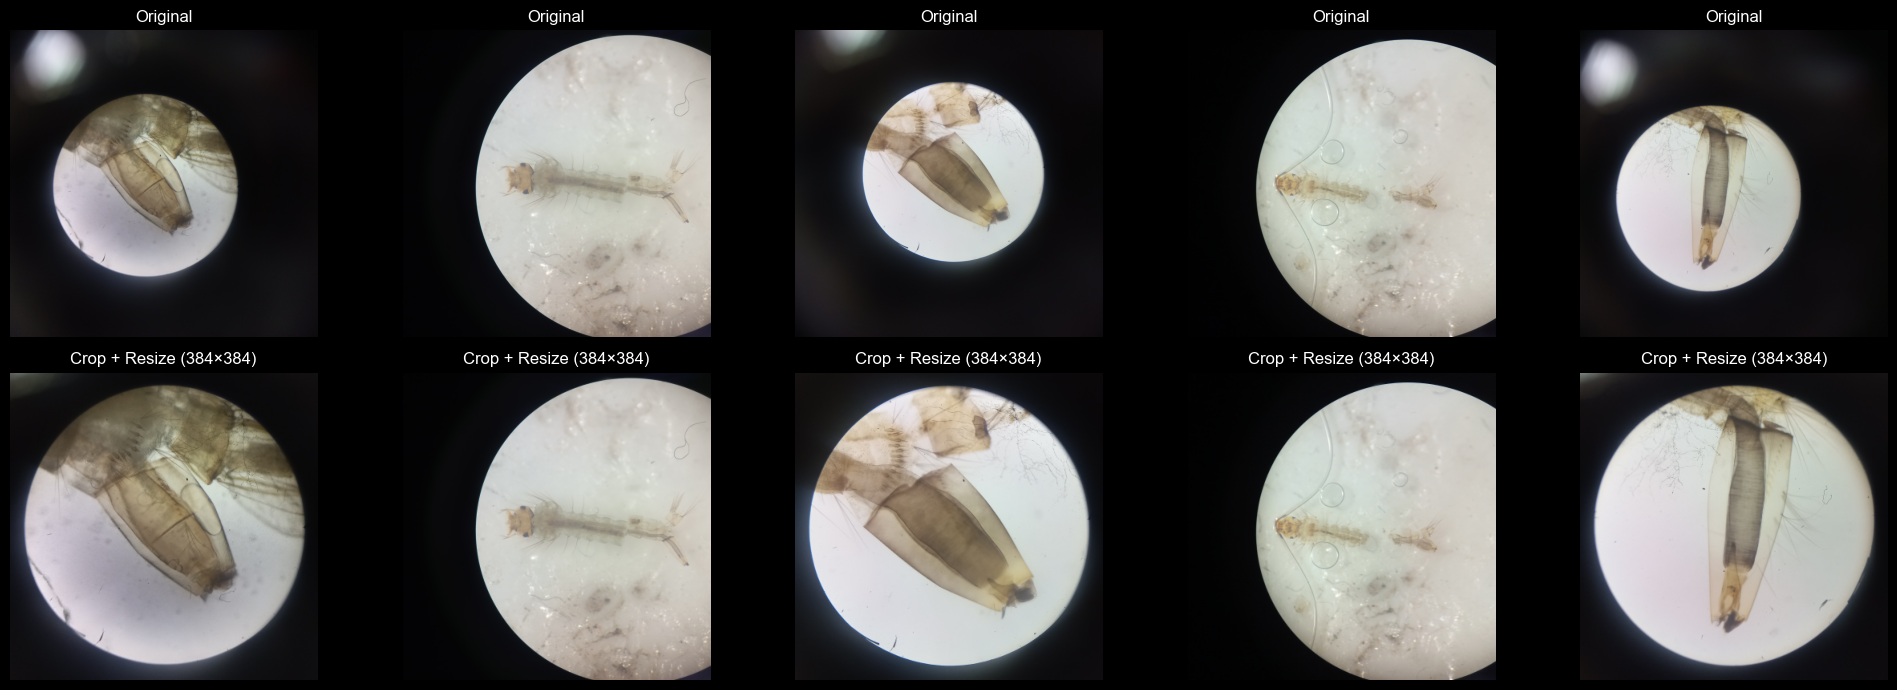

In [20]:
#Vista preliminar del preprocesamiento

dataset_raw = datasets.ImageFolder(DATASET_DIR)
indices = random.sample(range(len(dataset_raw)), N_PREVIEW)

plt.figure(figsize=(20, 7))

for i, idx in enumerate(indices):
    img_pil, label = dataset_raw[idx]

    # PIL → OpenCV
    img_rgb = np.array(img_pil)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    # Original
    plt.subplot(2, N_PREVIEW, i + 1)
    plt.imshow(img_pil)
    plt.title("Original")
    plt.axis("off")

    # Crop + Resize
    cropped = smart_crop_microscope(img_bgr)
    resized = high_quality_resize(cropped)

    # OpenCV → PIL para mostrar
    resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    resized_pil = Image.fromarray(resized_rgb)

    plt.subplot(2, N_PREVIEW, i + 1 + N_PREVIEW)
    plt.imshow(resized_pil)
    plt.title("Crop + Resize (384×384)")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:

# Preprocesar dataset completo

def preprocess_dataset(
    input_dir=DATASET_DIR,
    output_dir=OUTPUT_DIR
):
    for class_dir in input_dir.iterdir():
        if not class_dir.is_dir():
            continue

        print(f"Procesando clase: {class_dir.name}")

        for img_path in class_dir.glob("*.*"):
            img = cv2.imread(str(img_path))
            if img is None:
                continue

            # Crop adaptativo
            cropped = smart_crop_microscope(img)

            # Resize alta calidad
            resized = high_quality_resize(cropped)

            # Guardar
            out_path = output_dir / class_dir.name / img_path.name
            out_path.parent.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(out_path), resized)

    print("Dataset procesado y copiado correctamente")


In [22]:
preprocess_dataset()

Procesando clase: Aedes aegypti
Procesando clase: Culex quinquefasciatus
Dataset procesado y copiado correctamente


Aunque el redimensionamiento no produce cambios visuales drásticos,
este sí estandariza las dimensiones de entrada a 240×240 píxeles
manteniendo la relación de aspecto original. La ausencia de distorsión
visual confirma que la estrategia de resize con padding preserva la
morfología de las larvas, lo cual es deseable para tareas de clasificación.

“Si bien en la literatura se reporta el uso de redimensionamientos tempranos debido a las características del conjunto de datos original (640×480 píxeles), en el presente estudio se evaluó dicha estrategia sobre imágenes de mayor resolución (3456×3456 píxeles), no observándose una mejora visual ni geométrica significativa. En consecuencia, se decidió no aplicar un redimensionamiento destructivo durante el preprocesamiento geométrico, preservando la resolución original de las imágenes.”

### Etapa 4: División del conjunto de datos

In [23]:
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split

In [24]:
SOURCE_DIR = Path("dataset_processed")
TARGET_DIR = Path("dataset_split")

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}


In [25]:
image_paths = []
labels = []

classes = sorted([d.name for d in SOURCE_DIR.iterdir() if d.is_dir()])
class_to_idx = {cls: i for i, cls in enumerate(classes)}

for cls in classes:
    for img in (SOURCE_DIR / cls).iterdir():
        if img.suffix.lower() in VALID_EXTENSIONS:
            image_paths.append(img)
            labels.append(class_to_idx[cls])

print("Total imágenes:", len(image_paths))
print("Clases:", classes)

Total imágenes: 800
Clases: ['Aedes aegypti', 'Culex quinquefasciatus']


In [26]:
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,              # 15% val + 15% test
    stratify=labels,
    random_state=42
)

val_ratio = 0.5  # mitad de 30% → 15% y 15%

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=(1 - val_ratio),
    stratify=y_temp,
    random_state=42
)

In [27]:
for split in ["train", "val", "test"]:
    for cls in classes:
        (TARGET_DIR / split / cls).mkdir(parents=True, exist_ok=True)

In [28]:
def copy_files(files, labels, split_name):
    for img_path, label in zip(files, labels):
        cls_name = classes[label]
        shutil.copy2(
            img_path,
            TARGET_DIR / split_name / cls_name / img_path.name
        )

copy_files(X_train, y_train, "train")
copy_files(X_val, y_val, "val")
copy_files(X_test, y_test, "test")

In [29]:
# RESUMEN

print("Split completado con train_test_split\n")

for cls in classes:
    for split in ["train", "val", "test"]:
        count = len(list((TARGET_DIR / split / cls).iterdir()))
        print(f"{split.upper()} | {cls}: {count}")
    print("-" * 40)

Split completado con train_test_split

TRAIN | Aedes aegypti: 280
VAL | Aedes aegypti: 60
TEST | Aedes aegypti: 60
----------------------------------------
TRAIN | Culex quinquefasciatus: 280
VAL | Culex quinquefasciatus: 60
TEST | Culex quinquefasciatus: 60
----------------------------------------


Con el fin de garantizar una comparación justa entre los modelos propuestos, todos los experimentos fueron realizados utilizando la misma división del conjunto de datos en entrenamiento, validación y prueba. De este modo, las diferencias observadas en el desempeño de los modelos se atribuyen exclusivamente a las arquitecturas empleadas.

El split actual será utilizado para desarrollar y comparar los modelos:

1. CNN
2. CNN + ELM
3. ResNet18
4. EfficientNet_Lite0

### Etapa 5: Definición de arquitecturas CNN

En esta etapa se definió una red neuronal convolucional como extractor de características, inspirada en la arquitectura propuesta en la literatura, compuesta por cinco bloques de convolución y agrupación máxima. La CNN se emplea como base común para los modelos CNN pura y CNN-ELM.

Revisar los packages models

Se diseñó una red neuronal convolucional inspirada en arquitecturas CNN clásicas tipo AlexNet, adaptada mediante técnicas modernas de regularización y pooling global.